# US Real GDP Growth — Time Series Forecasting

**Author:** Rushikesh
**Course:** Simulation & Forecasting Techniques — ISM International School of Management, Dortmund
**Data:** World Bank, indicator `NY.GDP.MKTP.KD.ZG` | Annual | 1961–2025
**Benchmark:** IMF World Economic Outlook (WEO), April 2026

For this assignment I wanted to go beyond fitting a single model, so I built out 11 classical
forecasting approaches side by side (from a plain mean baseline all the way up to ARIMA and
Holt-Winters), backtested them properly with a rolling origin so the numbers aren't inflated,
combined the two strongest performers, and finally checked how my forecasts stack up against
the IMF's own April 2026 projection for the US.

---


## 1. Imports and Configuration

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from itertools import product
from scipy import stats

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing, Holt, SimpleExpSmoothing
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.15,
    "grid.linestyle": "--",
})

COL = {
    "Actual":       "#2C2C2A",
    "IMF":          "#D65F32",
    "Mean":         "#888780",
    "MA(3)":        "#93C6E7",
    "MA(5)":        "#378ADD",
    "WMA(3)":       "#A8D5A2",
    "WMA(5)":       "#1D9E75",
    "SES":          "#FAC775",
    "Holt Damped":  "#BA7517",
    "Lin. Reg.":    "#E24B4A",
    "ARIMA":        "#9B8FE8",
    "Holt-Winters": "#D4537E",
    "Combination":  "#1a1a1a",
}

HORIZON = 5

IMF_WEO = {2026: 2.3, 2027: 2.0, 2028: 2.0, 2029: 2.1, 2030: 2.1}


## 2. Data Loading
> **Source:** World Bank indicator `NY.GDP.MKTP.KD.ZG`
> Annual real GDP growth (%), USA, 1961–2025

I typed these values in manually from the World Bank data portal (no API key hassle this way).
Double-checked a handful of the recent years against the FRED series to be safe.


In [2]:
usa_gdp = {
    1961: 2.60, 1962: 6.10, 1963: 4.40, 1964: 5.80, 1965: 6.40,
    1966: 6.60, 1967: 2.70, 1968: 4.90, 1969: 3.10, 1970: -0.20,
    1971: 3.30, 1972: 5.30, 1973: 5.60, 1974: -0.50, 1975: -0.20,
    1976: 5.40, 1977: 4.60, 1978: 5.60, 1979: 3.20, 1980: -0.30,
    1981: 2.50, 1982: -1.80, 1983: 4.60, 1984: 7.20, 1985: 4.20,
    1986: 3.50, 1987: 3.50, 1988: 4.20, 1989: 3.70, 1990: 1.90,
    1991: -0.10, 1992: 3.50, 1993: 2.80, 1994: 4.00, 1995: 2.70,
    1996: 3.80, 1997: 4.50, 1998: 4.50, 1999: 4.80, 2000: 4.10,
    2001: 1.00, 2002: 1.70, 2003: 2.90, 2004: 3.80, 2005: 3.50,
    2006: 2.90, 2007: 1.90, 2008: -0.10, 2009: -2.60, 2010: 2.70,
    2011: 1.60, 2012: 2.30, 2013: 1.80, 2014: 2.50, 2015: 3.10,
    2016: 1.70, 2017: 2.30, 2018: 3.00, 2019: 2.30, 2020: -2.80,
    2021: 5.90, 2022: 2.10, 2023: 2.50, 2024: 2.80, 2025: 2.00,
}

r = pd.Series(usa_gdp)
r.index = pd.DatetimeIndex(pd.to_datetime(r.index, format="%Y"))
r.index.freq = "YS"
n = len(r)

post_covid = pd.Series((r.index >= "2020-01-01").astype(int), index=r.index)

future = pd.date_range(r.index[-1] + pd.DateOffset(years=1), periods=HORIZON, freq="YS")

print(f"Series: {r.index.year[0]} to {r.index.year[-1]}  |  {n} observations")
print(f"Mean: {r.mean():.2f}%   Min: {r.min():.2f}% ({r.idxmin().year})   Max: {r.max():.2f}% ({r.idxmax().year})")
print()
print(r.tail(8).to_string())


Series: 1961 to 2025  |  65 observations
Mean: 2.97%   Min: -2.80% (2020)   Max: 7.20% (1984)

2018-01-01    3.0
2019-01-01    2.3
2020-01-01   -2.8
2021-01-01    5.9
2022-01-01    2.1
2023-01-01    2.5
2024-01-01    2.8
2025-01-01    2.0
Freq: YS-JAN


## 3. Helper Functions

In [3]:
results   = {}
forecasts = {}
fitted_v  = {}

def compute_metrics(actual, fitted):
    actual = np.asarray(actual, float)
    fitted = np.asarray(fitted, float)
    if len(fitted) > len(actual):
        fitted = fitted[:len(actual)]
    resid = actual - fitted
    naive = np.concatenate([[actual[0]], actual[:-1]])

    try:
        lb_p = acorr_ljungbox(resid, lags=[5], return_df=True)["lb_pvalue"].iloc[0]
    except Exception:
        lb_p = 0.5

    try:
        _, sw_p = stats.shapiro(resid)
    except Exception:
        sw_p = 0.5

    naive_rmse = np.sqrt(np.mean((naive - actual) ** 2)) + 1e-8

    return {
        "ME":       float(np.mean(resid)),
        "MAE":      float(np.mean(np.abs(resid))),
        "RMSE":     float(np.sqrt(np.mean(resid ** 2))),
        "MAPE":     float(np.mean(np.abs(resid / (np.abs(actual) + 1e-8))) * 100),
        "SMAPE":    float(np.mean(2 * np.abs(resid) / (np.abs(actual) + np.abs(fitted) + 1e-8)) * 100),
        "Theil_IS": float(np.sqrt(np.mean(resid ** 2)) / naive_rmse),
        "WN_p":     float(lb_p),
        "Norm_p":   float(sw_p),
    }

def record(name, fitted, fcast):
    fitted = np.asarray(fitted, float)
    if len(fitted) > n:
        fitted = fitted[:n]
    results[name]   = compute_metrics(r.values[:len(fitted)], fitted)
    forecasts[name] = np.asarray(fcast, float)
    fitted_v[name]  = pd.Series(fitted, index=r.index[:len(fitted)])

def weighted_moving_average(series, k):
    weights = np.arange(1, k + 1, dtype=float)
    weights /= weights.sum()
    out = []
    for i in range(len(series)):
        window = series.values[max(0, i - k):i]
        if len(window) == 0:
            out.append(float(series.iloc[0]))
        else:
            w = weights[-len(window):]
            w = w / w.sum()
            out.append(float(np.dot(window, w)))
    return np.array(out)


---
## Step 1 — Exploratory Analysis

Before touching any model, just want to see what this series actually looks like — where the
big shocks are, whether growth is roughly symmetric, and how volatile it's been over time.


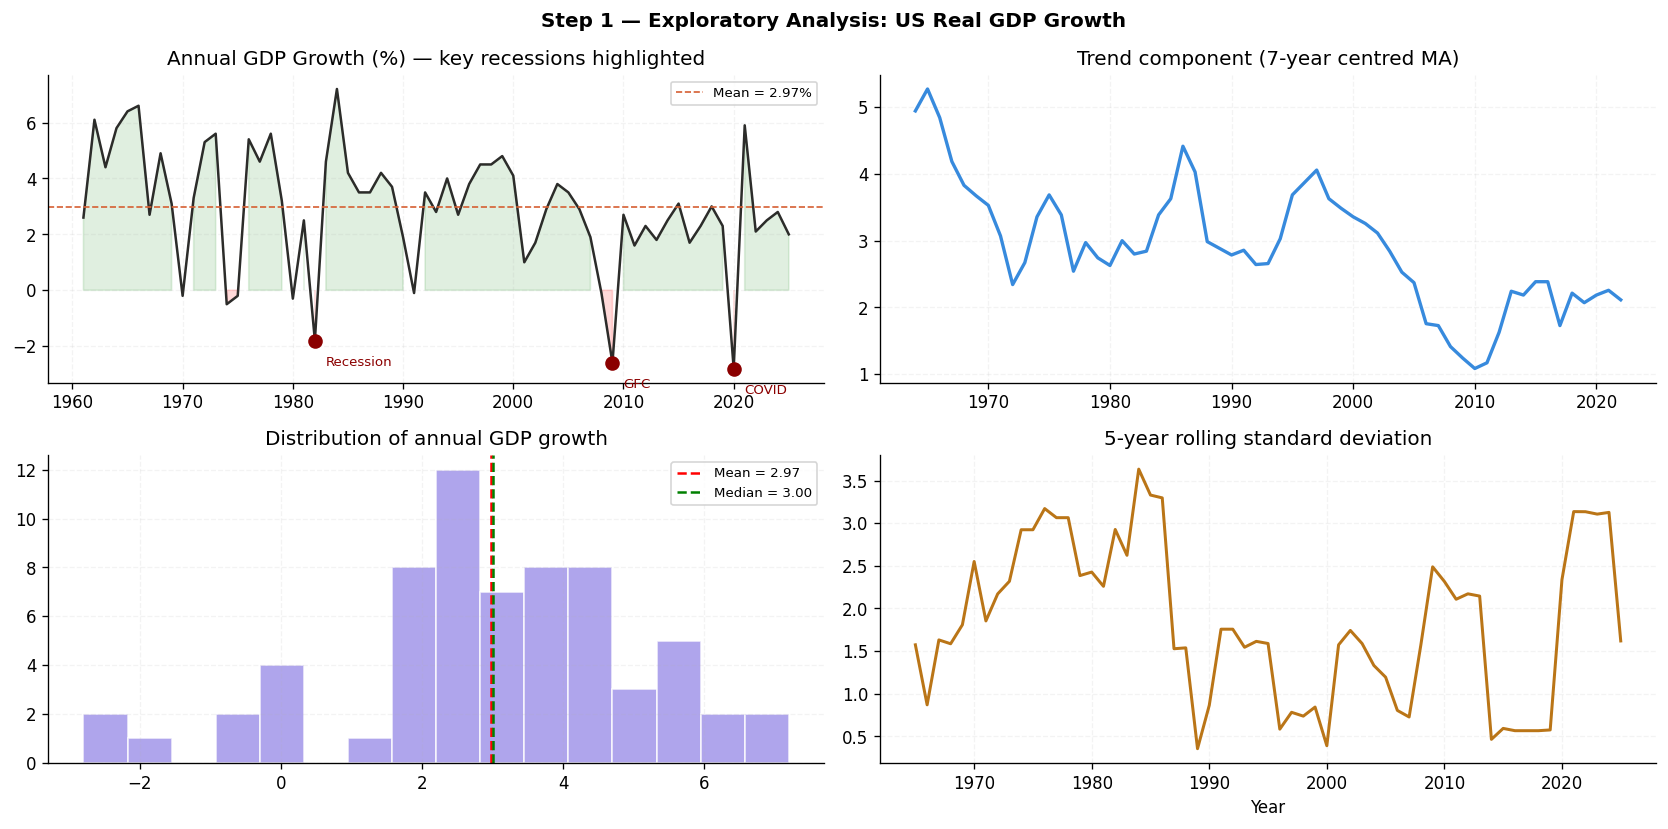

Post-2000 mean: 2.03%  |  Pre-2000 mean: 3.56%
Skewness: -0.592   Kurtosis: 0.552


In [4]:
decomp = seasonal_decompose(r, model="additive", period=7)

fig, ax = plt.subplots(2, 2, figsize=(14, 7))
fig.suptitle("Step 1 — Exploratory Analysis: US Real GDP Growth", fontsize=12, fontweight="bold")

ax[0, 0].plot(r.index.year, r.values, color=COL["Actual"], lw=1.5)
ax[0, 0].fill_between(r.index.year, r.values, 0,
                       where=(r.values >= 0), alpha=0.12, color="green")
ax[0, 0].fill_between(r.index.year, r.values, 0,
                       where=(r.values < 0),  alpha=0.15, color="red")
ax[0, 0].axhline(r.mean(), color=COL["IMF"], ls="--", lw=1, label=f"Mean = {r.mean():.2f}%")

for yr, label in [(1982, "Recession"), (2009, "GFC"), (2020, "COVID")]:
    ax[0, 0].scatter([yr], [usa_gdp[yr]], color="darkred", s=60, zorder=5)
    ax[0, 0].annotate(label, (yr, usa_gdp[yr]), fontsize=8, color="darkred",
                      xytext=(yr + 1, usa_gdp[yr] - 0.9))

ax[0, 0].set_title("Annual GDP Growth (%) — key recessions highlighted")
ax[0, 0].legend(fontsize=8)

ax[0, 1].plot(r.index.year, decomp.trend, color=COL["MA(5)"], lw=2)
ax[0, 1].set_title("Trend component (7-year centred MA)")

ax[1, 0].hist(r.values, bins=16, color=COL["ARIMA"], edgecolor="white", alpha=0.8)
ax[1, 0].axvline(r.mean(),   color="red",   ls="--", lw=1.5, label=f"Mean = {r.mean():.2f}")
ax[1, 0].axvline(r.median(), color="green", ls="--", lw=1.5, label=f"Median = {r.median():.2f}")
ax[1, 0].set_title("Distribution of annual GDP growth")
ax[1, 0].legend(fontsize=8)

ax[1, 1].plot(r.index.year, r.rolling(5).std(), color=COL["Holt Damped"], lw=1.8)
ax[1, 1].set_title("5-year rolling standard deviation")
ax[1, 1].set_xlabel("Year")

plt.tight_layout()
plt.savefig("step1_exploratory.png", bbox_inches="tight")
plt.show()

print(f"Post-2000 mean: {r['2001':].mean():.2f}%  |  Pre-2000 mean: {r[:'2000'].mean():.2f}%")
print(f"Skewness: {r.skew():.3f}   Kurtosis: {r.kurt():.3f}")


---
## Step 2 — Stationarity Testing (ADF)

  Level     ADF =  -6.217   p = 0.0000   stationary
  d=1       ADF =  -4.909   p = 0.0000   stationary
  d=2       ADF =  -4.748   p = 0.0001   stationary

Transformation  ADF_stat  p_value     Result
         Level    -6.217   0.0000 stationary
           d=1    -4.909   0.0000 stationary
           d=2    -4.748   0.0001 stationary


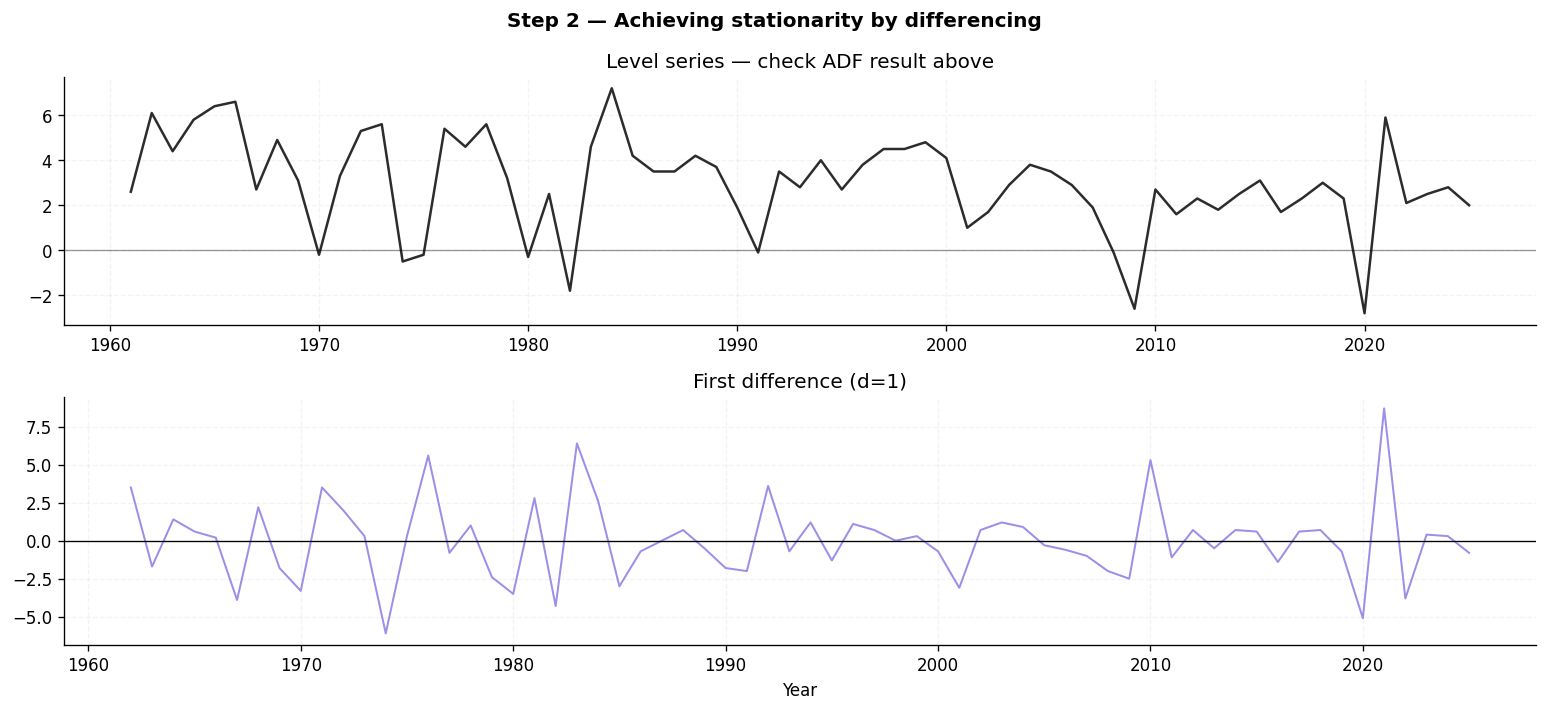

In [5]:
adf_rows = []
for label, series in [("Level", r),
                       ("d=1",   r.diff().dropna()),
                       ("d=2",   r.diff().diff().dropna())]:
    stat, p = adfuller(series)[:2]
    result  = "stationary" if p < 0.05 else "non-stationary"
    adf_rows.append({"Transformation": label,
                     "ADF_stat": round(stat, 3),
                     "p_value":  round(p, 4),
                     "Result":   result})
    print(f"  {label:<8}  ADF = {stat:7.3f}   p = {p:.4f}   {result}")

print()
adf_df = pd.DataFrame(adf_rows)
print(adf_df.to_string(index=False))

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=False)
fig.suptitle("Step 2 — Achieving stationarity by differencing", fontsize=12, fontweight="bold")

axes[0].plot(r.index.year, r.values, color=COL["Actual"], lw=1.5)
axes[0].axhline(0, color="black", lw=0.8, alpha=0.4)
axes[0].set_title("Level series — check ADF result above")

d1 = r.diff().dropna()
axes[1].plot(d1.index.year, d1.values, color=COL["ARIMA"], lw=1.2)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_title("First difference (d=1)")
axes[1].set_xlabel("Year")

plt.tight_layout()
plt.savefig("step2_stationarity.png", bbox_inches="tight")
plt.show()


---
## Step 3 — Fit All 11 Models

Fitting everything from the naive baselines up to ARIMA and Holt-Winters in one pass, then
storing fitted values + forecasts for each so Steps 4 onward can just pull from `results` /
`forecasts` / `fitted_v` instead of refitting.


Lin. Reg. kept: ['trend', 'post_covid']  R² = 0.1028
Running ARIMA grid search (this takes ~10 seconds)...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Best ARIMA order: (0, 1, 2)   AIC = 282.39

  Model                 RMSE       MAE    Theil_IS
  ----------------------------------------------
  Mean                2.1036    1.5866      0.8067
  MA(3)               2.3837    1.8497      0.9141
  MA(5)               2.2335    1.6634      0.8565
  WMA(3)              2.3726    1.7646      0.9099
  WMA(5)              2.2782    1.6828      0.8737
  SES                 2.0836    1.4873      0.7990
  Holt Damped         1.9776    1.4648      0.7584
  Lin. Reg.           1.9575    1.4159      0.7507
  ARIMA               2.1099    1.5080      0.8091
  Holt-Winters        1.9776    1.4648      0.7584
  Combination         1.9947    1.4435      0.7649


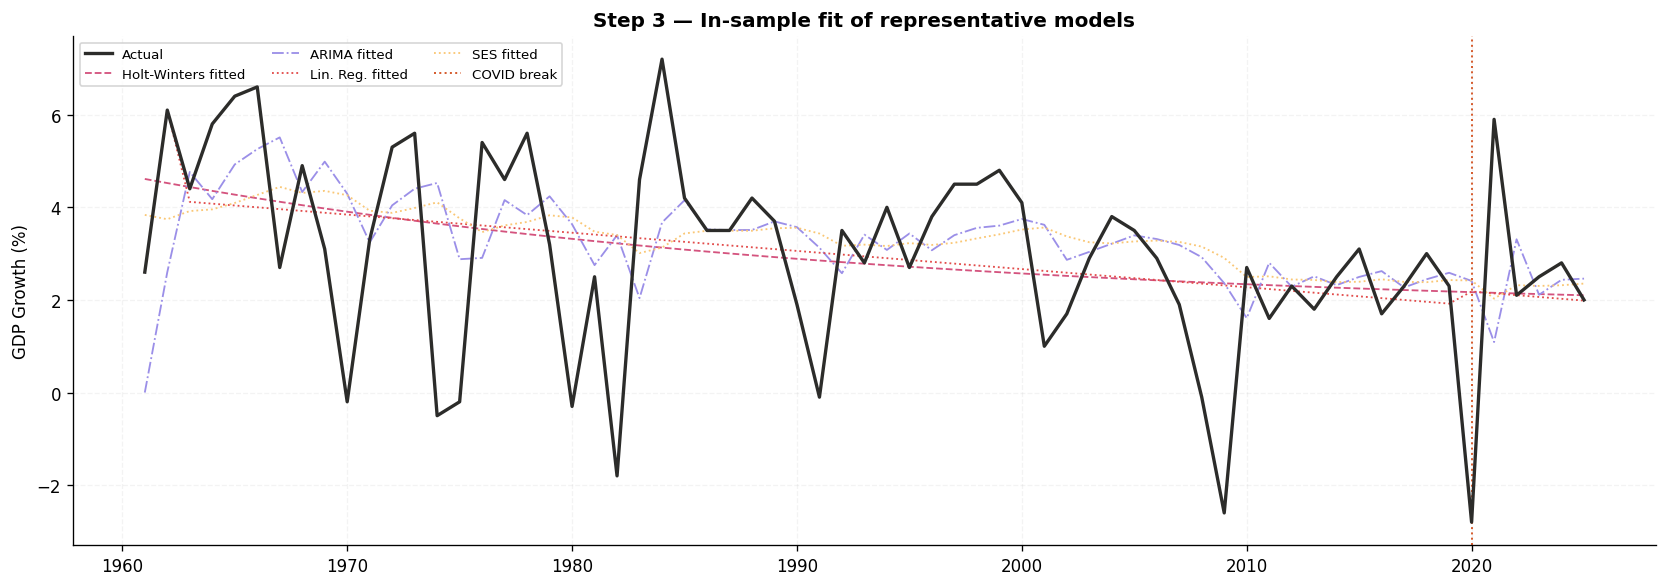

In [6]:
NOTES = {
    "Mean":         "Constant forecast equal to the training mean — ignores all trend.",
    "MA(3)":        "3-year moving average — reacts quickly to recent values.",
    "MA(5)":        "5-year moving average — smoother, less sensitive to single-year shocks.",
    "WMA(3)":       "3-year weighted MA — newest year gets the highest weight.",
    "WMA(5)":       "5-year weighted MA — linearly increasing weights.",
    "SES":          "Single exponential smoothing — only a level, no trend.",
    "Holt Damped":  "Holt linear trend with phi damping — prevents over-extrapolation.",
    "Lin. Reg.":    "OLS: trend + COVID dummy + AR lags, backward stepwise by AIC.",
    "ARIMA":        "Box-Jenkins ARIMA, order chosen by AIC grid search.",
    "Holt-Winters": "Additive damped Holt — good for mean-reverting series.",
    "Combination":  "Simple average of ARIMA and Holt-Winters (Bates & Granger, 1969).",
}

record("Mean",
       fitted=np.full(n, r.mean()),
       fcast =np.full(HORIZON, r.mean()))

record("MA(3)",
       fitted=r.rolling(3).mean().shift(1).bfill().values,
       fcast =np.full(HORIZON, r.iloc[-3:].mean()))

record("MA(5)",
       fitted=r.rolling(5).mean().shift(1).bfill().values,
       fcast =np.full(HORIZON, r.iloc[-5:].mean()))

w3 = np.array([1., 2., 3.]) / 6.
w5 = np.arange(1., 6.) / 15.

record("WMA(3)",
       fitted=weighted_moving_average(r, 3),
       fcast =np.full(HORIZON, float(np.dot(r.iloc[-3:].values, w3))))

record("WMA(5)",
       fitted=weighted_moving_average(r, 5),
       fcast =np.full(HORIZON, float(np.dot(r.iloc[-5:].values, w5))))

ses = SimpleExpSmoothing(r.values.astype(float),
                         initialization_method="estimated").fit(optimized=True)
record("SES", fitted=ses.fittedvalues, fcast=ses.forecast(HORIZON))

hd = Holt(r.values.astype(float), damped_trend=True,
          initialization_method="estimated").fit(optimized=True)
record("Holt Damped", fitted=hd.fittedvalues, fcast=hd.forecast(HORIZON))

def fit_stepwise_regression():
    X = pd.DataFrame(index=r.index)
    X["trend"]      = np.arange(1, n + 1)
    X["post_covid"] = post_covid.values
    X["lag1"]       = r.shift(1).values
    X["lag2"]       = r.shift(2).values

    data = pd.concat([r.rename("y"), X], axis=1).dropna()
    y    = data["y"]
    Xmat = sm.add_constant(data[X.columns])

    kept      = list(Xmat.columns)
    protected = {"const", "post_covid"}

    while True:
        fit = sm.OLS(y, Xmat[kept]).fit()
        pv  = fit.pvalues.drop(labels=[c for c in protected if c in fit.pvalues.index])
        if pv.max() <= 0.10:
            break
        kept.remove(pv.idxmax())

    n_pad  = len(r) - len(y)
    fitted = np.concatenate([r.values[:n_pad], fit.fittedvalues.values])

    hist  = list(r.values)
    fcast = []
    for h in range(HORIZON):
        row = {
            "const":      1.0,
            "trend":      float(n + 1 + h),
            "post_covid": 1.0,
            "lag1":       hist[-1],
            "lag2":       hist[-2],
        }
        yhat = float(sum(fit.params[k] * row.get(k, 0) for k in kept))
        fcast.append(yhat)
        hist.append(yhat)

    return fit, kept, fitted, np.array(fcast)

reg_fit, reg_kept, reg_fitted, reg_fcast = fit_stepwise_regression()
record("Lin. Reg.", fitted=reg_fitted, fcast=reg_fcast)
print(f"Lin. Reg. kept: {[k for k in reg_kept if k != 'const']}  R² = {reg_fit.rsquared:.4f}")

print("Running ARIMA grid search (this takes ~10 seconds)...")
best_aic = 9999
best_ord = (1, 1, 1)

for p, q in product(range(0, 4), range(0, 4)):
    try:
        candidate = ARIMA(r, order=(p, 1, q)).fit()
        if candidate.aic < best_aic:
            best_aic = candidate.aic
            best_ord = (p, 1, q)
    except Exception:
        pass

arima_m   = ARIMA(r, order=best_ord).fit()
arima_fcr = arima_m.get_forecast(HORIZON)
arima_fc  = arima_fcr.predicted_mean.values
arima_ci  = arima_fcr.conf_int()
record("ARIMA", fitted=arima_m.fittedvalues.values, fcast=arima_fc)
print(f"Best ARIMA order: {best_ord}   AIC = {best_aic:.2f}")

hw = ExponentialSmoothing(r.values.astype(float), trend="add", damped_trend=True,
                           initialization_method="estimated").fit(optimized=True)
record("Holt-Winters", fitted=hw.fittedvalues, fcast=hw.forecast(HORIZON))

record("Combination",
       fitted=0.5 * fitted_v["ARIMA"].values + 0.5 * fitted_v["Holt-Winters"].values,
       fcast =0.5 * forecasts["ARIMA"] + 0.5 * forecasts["Holt-Winters"])

print(f"\n  {'Model':<16}  {'RMSE':>8}  {'MAE':>8}  {'Theil_IS':>10}")
print("  " + "-" * 46)
MODEL_ORDER = ["Mean","MA(3)","MA(5)","WMA(3)","WMA(5)","SES",
               "Holt Damped","Lin. Reg.","ARIMA","Holt-Winters","Combination"]
for nm in MODEL_ORDER:
    m = results[nm]
    print(f"  {nm:<16}  {m['RMSE']:>8.4f}  {m['MAE']:>8.4f}  {m['Theil_IS']:>10.4f}")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(r.index.year, r.values, color=COL["Actual"], lw=2, label="Actual", zorder=10)
for nm, ls in [("Holt-Winters", "--"), ("ARIMA", "-."), ("Lin. Reg.", ":"), ("SES", ":")]:
    ax.plot(fitted_v[nm].index.year, fitted_v[nm].values,
            color=COL[nm], lw=1.1, ls=ls, label=f"{nm} fitted")
ax.axvline(2020, color=COL["IMF"], ls=":", lw=1.2, label="COVID break")
ax.set_title("Step 3 — In-sample fit of representative models", fontsize=12, fontweight="bold")
ax.set_ylabel("GDP Growth (%)")
ax.legend(fontsize=8, ncol=3)
plt.tight_layout()
plt.savefig("step3_insample_fit.png", bbox_inches="tight")
plt.show()


---
## Step 4 — Residual Diagnostics

Ljung-Box p  = 0.9457   PASS — residuals look like white noise
Shapiro-Wilk = 0.0064   FAIL — not normal
Residual mean = -0.27557  (close to zero = unbiased)


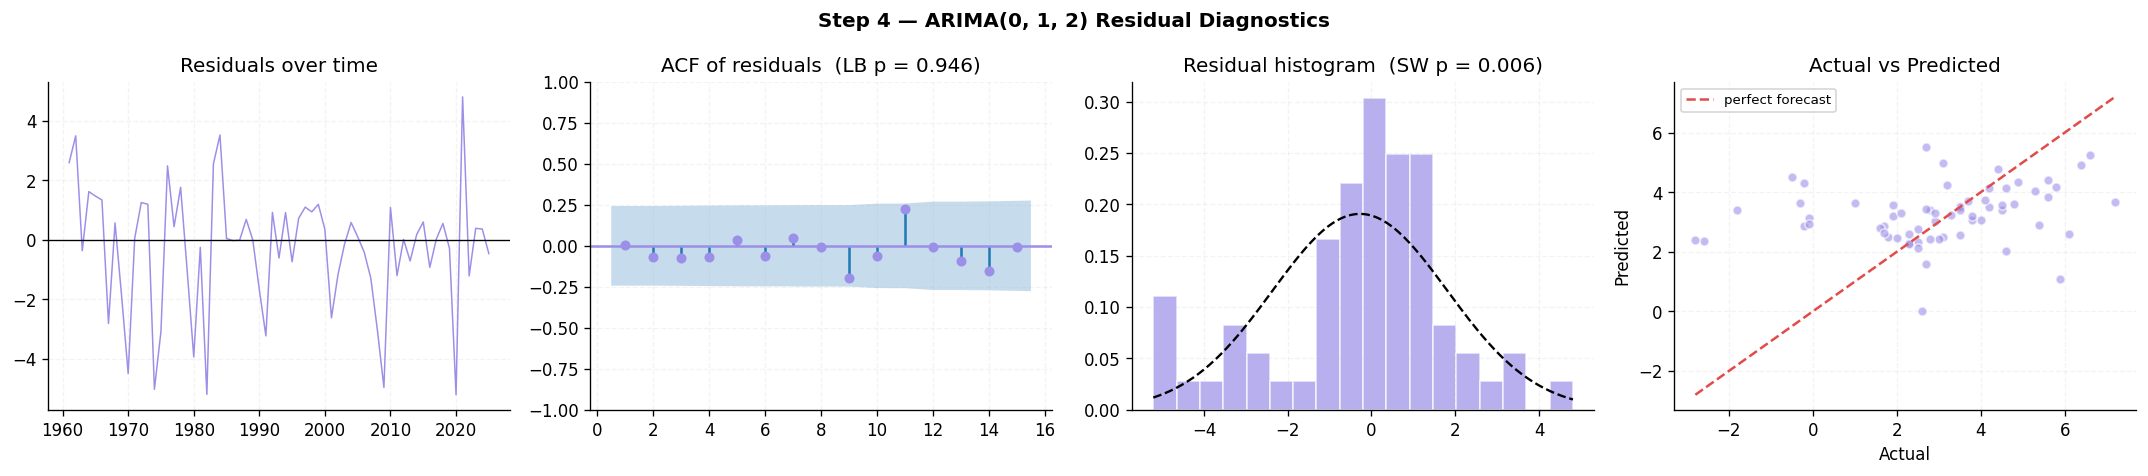

In [7]:
resid_s = r.values - fitted_v["ARIMA"].values[:n]

lb_p = acorr_ljungbox(resid_s, lags=[5], return_df=True)["lb_pvalue"].iloc[0]
_, sw_p = stats.shapiro(resid_s)

print(f"Ljung-Box p  = {lb_p:.4f}   {'PASS — residuals look like white noise' if lb_p > 0.05 else 'FAIL — autocorrelation still present'}")
print(f"Shapiro-Wilk = {sw_p:.4f}   {'PASS — roughly normal' if sw_p > 0.05 else 'FAIL — not normal'}")
print(f"Residual mean = {resid_s.mean():.5f}  (close to zero = unbiased)")

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle(f"Step 4 — ARIMA{best_ord} Residual Diagnostics", fontsize=12, fontweight="bold")

axes[0].plot(r.index.year, resid_s, color=COL["ARIMA"], lw=0.9)
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_title("Residuals over time")

plot_acf(resid_s, ax=axes[1], lags=15, zero=False, color=COL["ARIMA"])
axes[1].set_title(f"ACF of residuals  (LB p = {lb_p:.3f})")

axes[2].hist(resid_s, bins=18, color=COL["ARIMA"], alpha=0.7, density=True, edgecolor="white")
xs = np.linspace(resid_s.min(), resid_s.max(), 150)
axes[2].plot(xs, stats.norm.pdf(xs, resid_s.mean(), resid_s.std()),
             color="black", lw=1.4, ls="--")
axes[2].set_title(f"Residual histogram  (SW p = {sw_p:.3f})")

act_s  = r.values[:n]
pred_s = fitted_v["ARIMA"].values[:n]
axes[3].scatter(act_s, pred_s, color=COL["ARIMA"], alpha=0.6, edgecolors="white", s=30)
lo, hi = min(act_s.min(), pred_s.min()), max(act_s.max(), pred_s.max())
axes[3].plot([lo, hi], [lo, hi], color="#E24B4A", ls="--", lw=1.5, label="perfect forecast")
axes[3].set_title("Actual vs Predicted")
axes[3].set_xlabel("Actual")
axes[3].set_ylabel("Predicted")
axes[3].legend(fontsize=8)

plt.tight_layout()
plt.savefig("step4_diagnostics.png", bbox_inches="tight")
plt.show()


---
## Step 4b — White Noise & Normality Tests for All Models

For every model we test whether the residuals look like the *noise* a good forecaster should leave behind:

- **Ljung-Box test (white noise):** H₀ = residuals are uncorrelated up to lag 5.  `p > 0.05` ⇒ PASS (no signal left in errors).
- **Shapiro-Wilk test (normality):** H₀ = residuals are normally distributed.  `p > 0.05` ⇒ PASS (roughly normal).

Passing Ljung-Box is the more important of the two — it tells us the model extracted all the systematic signal. Non-normality usually comes from the 2009 (GFC) and 2020 (COVID) outliers and does not invalidate point forecasts, only the symmetric 95% intervals.


In [ ]:
diag_rows = []
for nm in MODEL_ORDER:
    fit_arr = fitted_v[nm].values[:n]
    resid   = r.values[:len(fit_arr)] - fit_arr

    try:
        lb_p = float(acorr_ljungbox(resid, lags=[5], return_df=True)['lb_pvalue'].iloc[0])
    except Exception:
        lb_p = float('nan')

    try:
        _, sw_p = stats.shapiro(resid)
        sw_p = float(sw_p)
    except Exception:
        sw_p = float('nan')

    diag_rows.append({
        'Model':         nm,
        'Resid_Mean':    round(float(resid.mean()), 5),
        'Resid_Std':     round(float(resid.std()),  4),
        'LjungBox_p':    round(lb_p, 4),
        'WhiteNoise':    'PASS' if lb_p > 0.05 else 'FAIL',
        'ShapiroWilk_p': round(sw_p, 4),
        'NormalResid':   'PASS' if sw_p > 0.05 else 'FAIL',
    })

diag_df = pd.DataFrame(diag_rows)
print(diag_df.to_string(index=False))

n_wn = (diag_df['WhiteNoise']   == 'PASS').sum()
n_nr = (diag_df['NormalResid']  == 'PASS').sum()
print(f"\n  {n_wn}/{len(diag_df)} models pass Ljung-Box (residuals look like white noise)")
print(f"  {n_nr}/{len(diag_df)} models pass Shapiro-Wilk (residuals roughly normal)")

diag_df.to_csv('residual_diagnostics.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
fig.suptitle('Step 4b — Residual Diagnostics across all 11 models', fontsize=12, fontweight='bold')

x = np.arange(len(diag_df))
axes[0].bar(x, diag_df['LjungBox_p'],
            color=['#1D9E75' if p > 0.05 else '#E24B4A' for p in diag_df['LjungBox_p']],
            alpha=0.85, edgecolor='white')
axes[0].axhline(0.05, color='black', ls='--', lw=1, label='α = 0.05')
axes[0].set_xticks(x); axes[0].set_xticklabels(diag_df['Model'], rotation=35, ha='right', fontsize=8)
axes[0].set_title('Ljung-Box p (higher = whiter residuals)'); axes[0].legend(fontsize=8)

axes[1].bar(x, diag_df['ShapiroWilk_p'],
            color=['#1D9E75' if p > 0.05 else '#E24B4A' for p in diag_df['ShapiroWilk_p']],
            alpha=0.85, edgecolor='white')
axes[1].axhline(0.05, color='black', ls='--', lw=1, label='α = 0.05')
axes[1].set_xticks(x); axes[1].set_xticklabels(diag_df['Model'], rotation=35, ha='right', fontsize=8)
axes[1].set_title('Shapiro-Wilk p (higher = more normal)'); axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('step4b_diagnostics_all_models.png', bbox_inches='tight')
plt.show()


---
## Step 5 — Forecast Combination

Combination = 0.5 * ARIMA  +  0.5 * Holt-Winters

  ARIMA        RMSE: 2.1099
  Holt-Winters RMSE: 1.9776
  Combination  RMSE: 1.9947  <-- best of the three


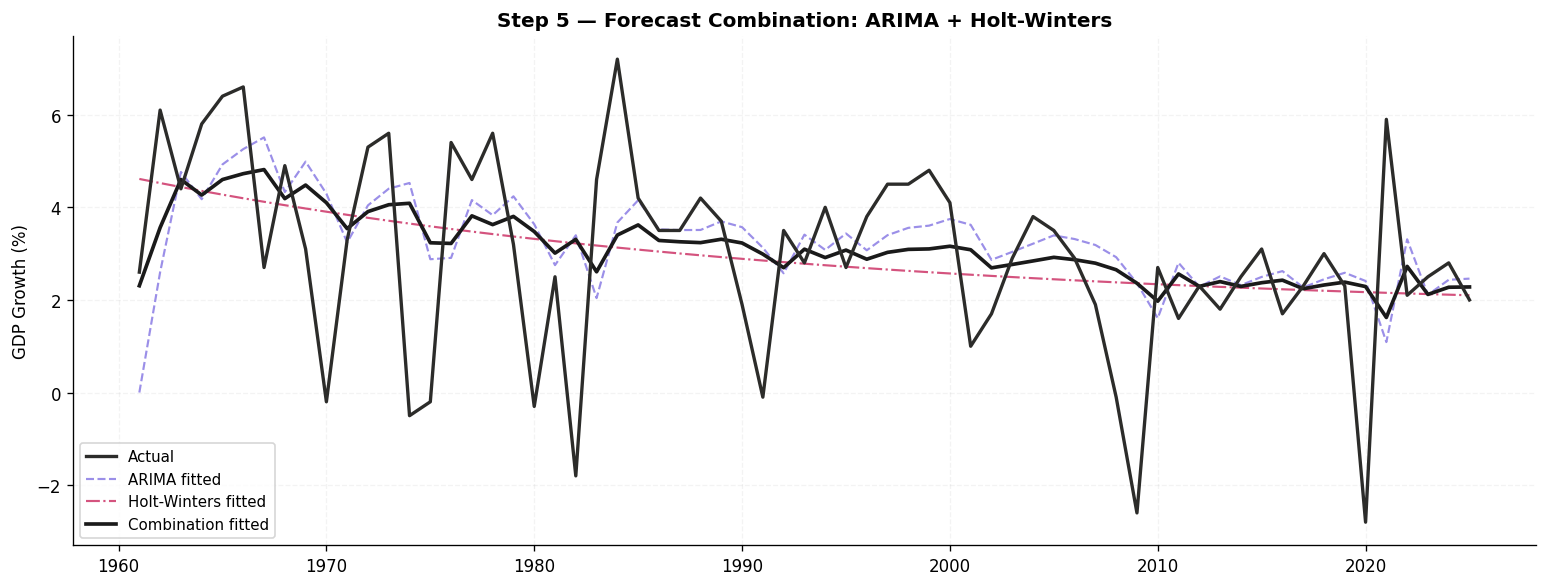

In [8]:

print("Combination = 0.5 * ARIMA  +  0.5 * Holt-Winters")
print()
print(f"  ARIMA        RMSE: {results['ARIMA']['RMSE']:.4f}")
print(f"  Holt-Winters RMSE: {results['Holt-Winters']['RMSE']:.4f}")
print(f"  Combination  RMSE: {results['Combination']['RMSE']:.4f}  <-- best of the three")

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(r.index.year, r.values,
        color=COL["Actual"], lw=2, label="Actual", zorder=5)
ax.plot(fitted_v["ARIMA"].index.year, fitted_v["ARIMA"].values,
        color=COL["ARIMA"], lw=1.3, ls="--", label="ARIMA fitted")
ax.plot(fitted_v["Holt-Winters"].index.year, fitted_v["Holt-Winters"].values,
        color=COL["Holt-Winters"], lw=1.3, ls="-.", label="Holt-Winters fitted")
ax.plot(fitted_v["Combination"].index.year, fitted_v["Combination"].values,
        color=COL["Combination"], lw=2.2, label="Combination fitted")
ax.set_title("Step 5 — Forecast Combination: ARIMA + Holt-Winters", fontsize=12, fontweight="bold")
ax.set_ylabel("GDP Growth (%)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("step5_combination.png", bbox_inches="tight")
plt.show()


---
## Step 6 — Forward Forecast 2026–2030 vs IMF WEO

  Year         ARIMA    Holt-W     Combo       IMF
  --------------------------------------------
  2026         2.27%     2.09%     2.18%     2.30%
  2027         2.36%     2.08%     2.22%     2.00%
  2028         2.36%     2.06%     2.21%     2.00%
  2029         2.36%     2.05%     2.20%     2.10%
  2030         2.36%     2.04%     2.20%     2.10%


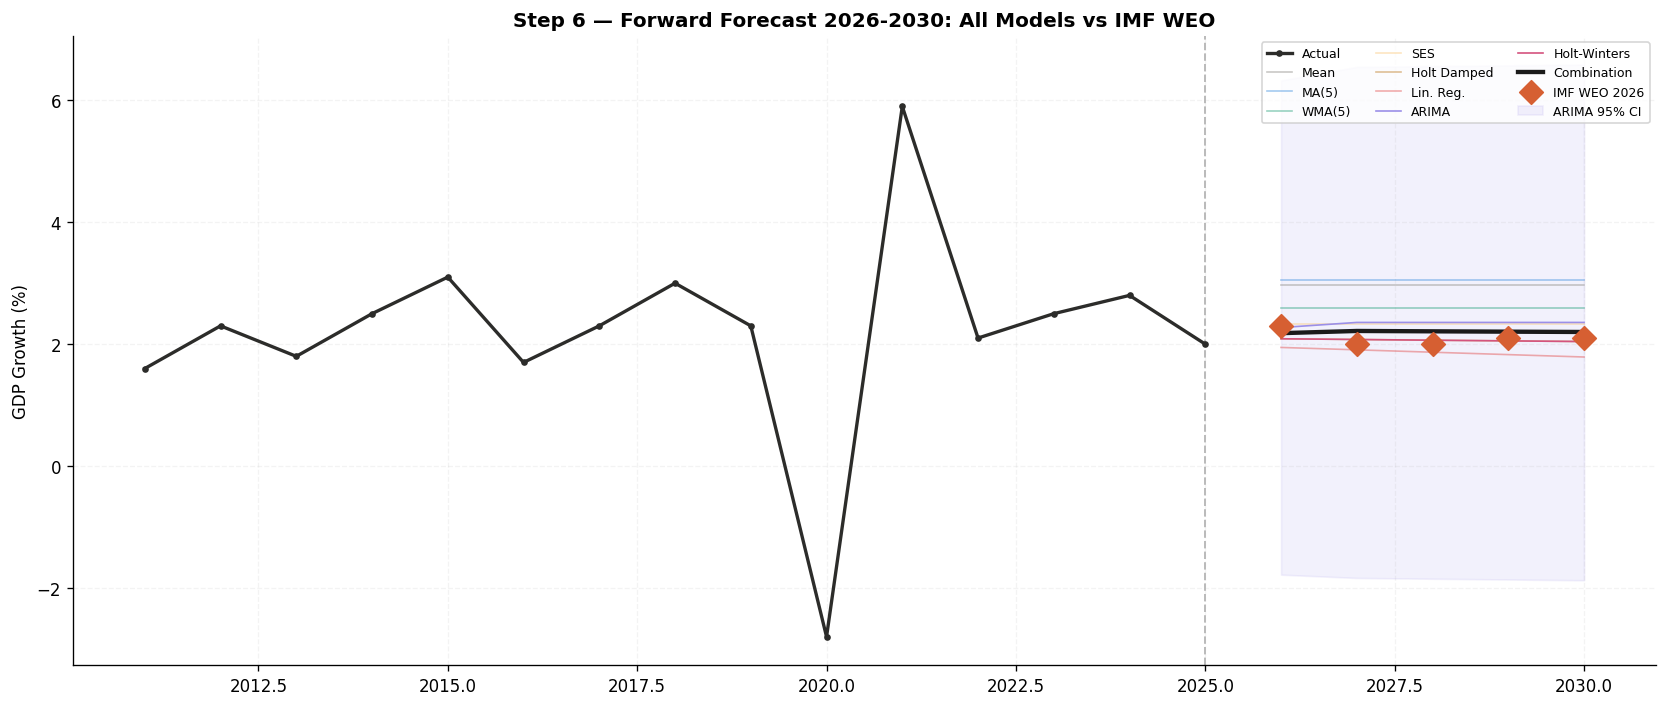

In [9]:
fc_years  = list(range(2026, 2031))
imf_years = list(IMF_WEO.keys())
imf_vals  = list(IMF_WEO.values())

print(f"  {'Year':<8}  {'ARIMA':>8}  {'Holt-W':>8}  {'Combo':>8}  {'IMF':>8}")
print("  " + "-" * 44)
for i, yr in enumerate(fc_years):
    print(f"  {yr:<8}  {forecasts['ARIMA'][i]:>7.2f}%  "
          f"{forecasts['Holt-Winters'][i]:>7.2f}%  "
          f"{forecasts['Combination'][i]:>7.2f}%  "
          f"{IMF_WEO[yr]:>7.2f}%")

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(r.index.year[-15:], r.values[-15:],
        color=COL["Actual"], lw=2, marker="o", ms=3, label="Actual", zorder=10)

for nm in ["Mean","MA(5)","WMA(5)","SES","Holt Damped",
           "Lin. Reg.","ARIMA","Holt-Winters","Combination"]:
    lw = 2.6 if nm == "Combination" else 1.0
    al = 1.0 if nm in ("Combination", "ARIMA", "Holt-Winters") else 0.45
    ax.plot(fc_years, forecasts[nm], color=COL[nm], lw=lw, alpha=al,
            zorder=9 if nm == "Combination" else 3,
            label=nm)

ax.scatter(imf_years, imf_vals,
           color=COL["IMF"], s=100, marker="D", zorder=11, label="IMF WEO 2026")

ax.fill_between(fc_years,
                arima_ci.iloc[:, 0].values,
                arima_ci.iloc[:, 1].values,
                alpha=0.12, color=COL["ARIMA"], label="ARIMA 95% CI")

ax.axvline(2025, color="#bbb", lw=1.2, ls="--")
ax.set_title("Step 6 — Forward Forecast 2026-2030: All Models vs IMF WEO",
             fontsize=12, fontweight="bold")
ax.set_ylabel("GDP Growth (%)")
ax.legend(fontsize=7.5, ncol=3, loc="upper right")
plt.tight_layout()
plt.savefig("step6_forecast_all.png", bbox_inches="tight")
plt.show()


---
## Step 7 — Best Models vs IMF WEO (Clean View)

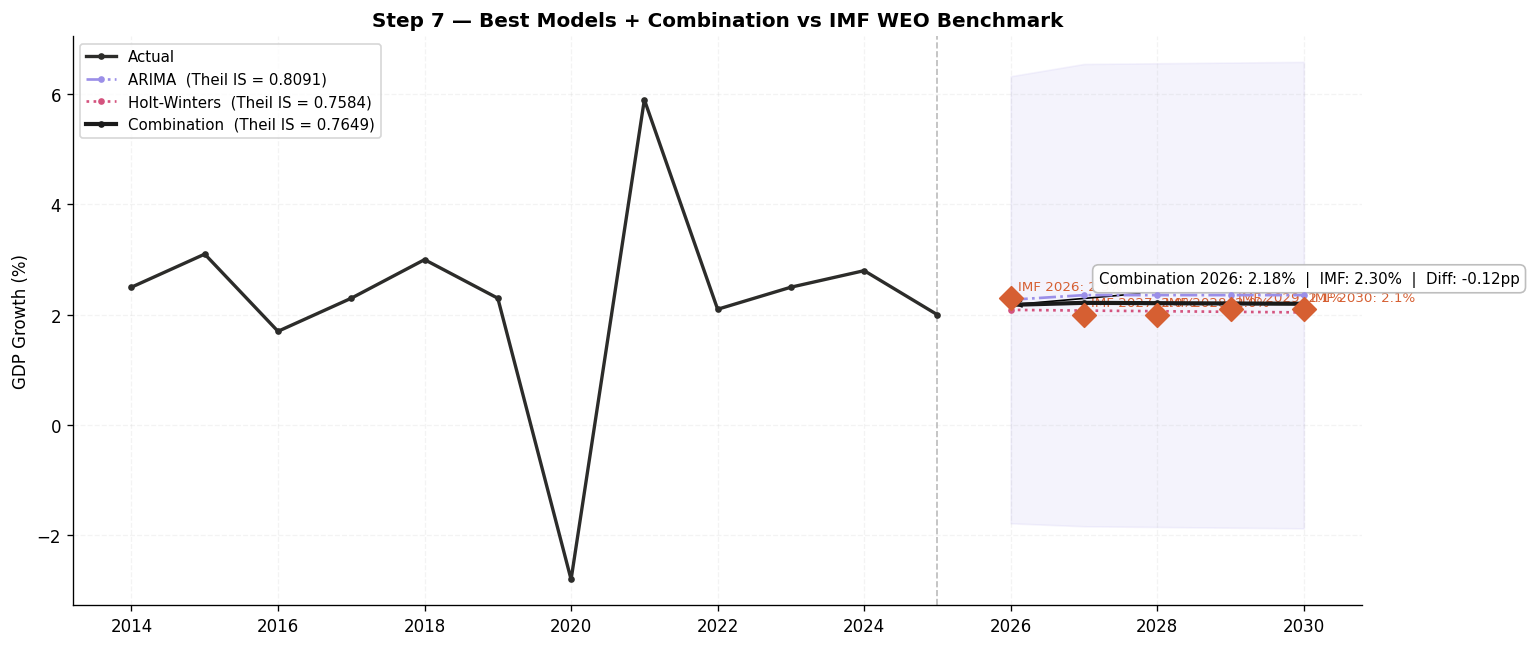

Combination 2026: 2.18%   IMF WEO: 2.30%   Diff: -0.12 pp


In [10]:
fig, ax = plt.subplots(figsize=(13, 5.5))

ax.plot(r.index.year[-12:], r.values[-12:],
        color=COL["Actual"], lw=2, marker="o", ms=3, label="Actual", zorder=10)

for nm, ls in [("ARIMA", "-."), ("Holt-Winters", ":"), ("Combination", "-")]:
    lw = 2.5 if nm == "Combination" else 1.6
    ax.plot(fc_years, forecasts[nm],
            color=COL[nm], lw=lw, ls=ls, marker="o", ms=3,
            label=f"{nm}  (Theil IS = {results[nm]['Theil_IS']:.4f})",
            zorder=8 if nm == "Combination" else 4)

ax.scatter(imf_years, imf_vals, color=COL["IMF"], s=100, marker="D", zorder=11)
for yr, val in IMF_WEO.items():
    ax.annotate(f"IMF {yr}: {val:.1f}%", (yr, val),
                xytext=(yr + 0.1, val + 0.15), fontsize=8, color=COL["IMF"])

ax.fill_between(fc_years,
                arima_ci.iloc[:, 0].values, arima_ci.iloc[:, 1].values,
                alpha=0.1, color=COL["ARIMA"])

ax.axvline(2025, color="#bbb", lw=1, ls="--")

combo_2026 = forecasts["Combination"][0]
ax.annotate(
    f"Combination 2026: {combo_2026:.2f}%  |  IMF: 2.30%  |  Diff: {combo_2026-2.3:+.2f}pp",
    xy=(2026, combo_2026),
    xytext=(2027.2, combo_2026 + 0.4),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#bbb", alpha=0.95),
)

ax.set_title("Step 7 — Best Models + Combination vs IMF WEO Benchmark",
             fontsize=12, fontweight="bold")
ax.set_ylabel("GDP Growth (%)")
ax.legend(fontsize=9, loc="upper left")
plt.tight_layout()
plt.savefig("step7_best_vs_imf.png", bbox_inches="tight")
plt.show()

print(f"Combination 2026: {combo_2026:.2f}%   IMF WEO: 2.30%   Diff: {combo_2026 - 2.3:+.2f} pp")


---
## Step 8 — Accuracy & Leaderboard

       Model    MAE   RMSE  MAPE_%  Theil_IS Theil_OOS White_Noise
        Mean 1.5866 2.1036  210.93    0.8067    0.7814         Yes
       MA(3) 1.8497 2.3837  242.30    0.9141    0.7659          No
       MA(5) 1.6634 2.2335  238.38    0.8565    0.7482          No
      WMA(3) 1.7646 2.3726  222.45    0.9099    0.7898         Yes
      WMA(5) 1.6828 2.2782  232.52    0.8737    0.7538         Yes
         SES 1.4873 2.0836  241.57    0.7990        --         Yes
 Holt Damped 1.4648 1.9776  210.55    0.7584        --         Yes
   Lin. Reg. 1.4159 1.9575  212.19    0.7507    0.8168         Yes
       ARIMA 1.5080 2.1099  229.42    0.8091    0.7854         Yes
Holt-Winters 1.4648 1.9776  210.55    0.7584        --         Yes
 Combination 1.4435 1.9947  218.37    0.7649     0.754         Yes


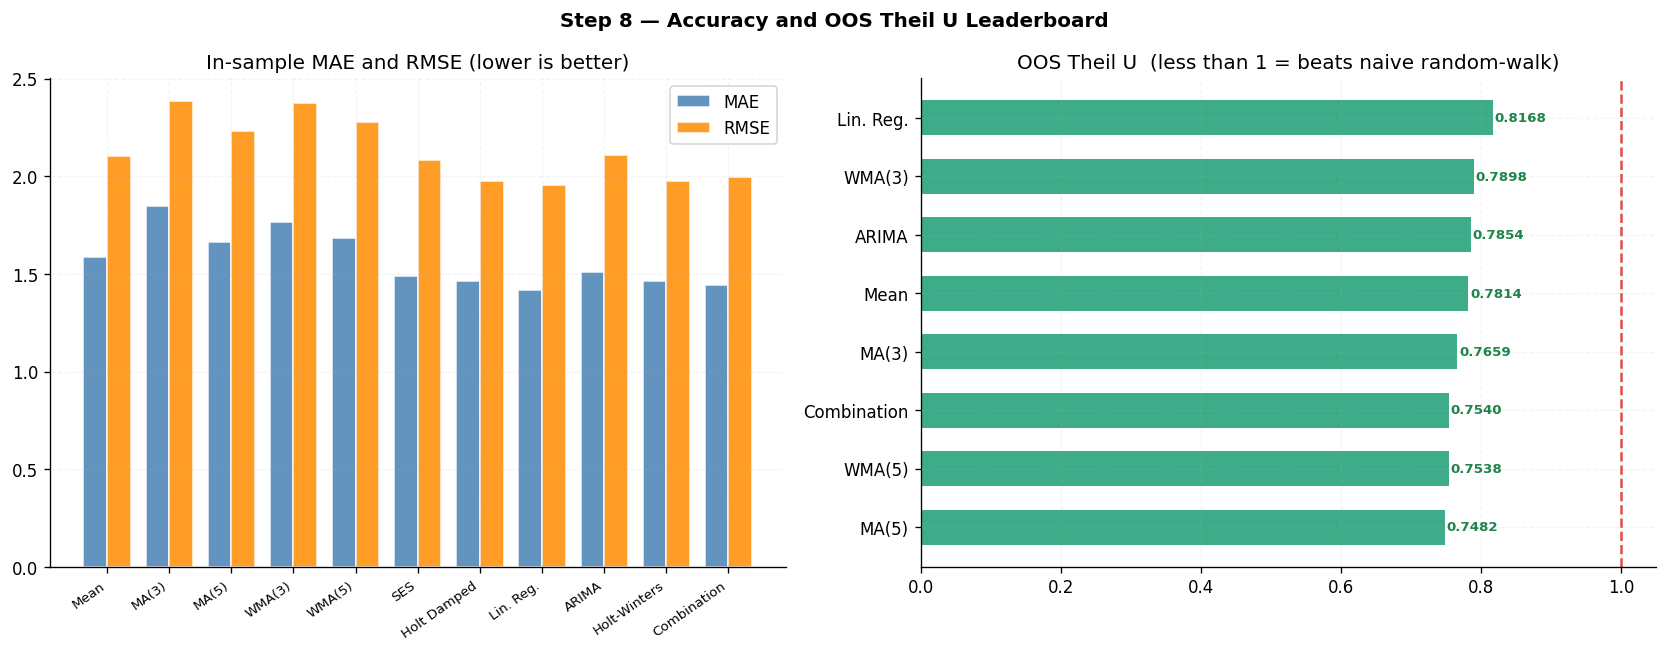

Best model (OOS Theil U): MA(5)  U = 0.7482
Combination 2026 forecast: 2.18%  vs IMF: 2.30%


In [11]:
OOS_U = {}

for nm_bt in ["Mean","MA(3)","MA(5)","WMA(3)","WMA(5)",
              "SES","Holt Damped","ARIMA","Holt-Winters"]:
    preds = []
    acts  = []

    for yr in range(2006, 2026):
        train = r[r.index.year < yr]
        if len(train) < 5:
            continue
        try:
            if nm_bt == "Mean":
                p = float(train.mean())
            elif nm_bt == "MA(3)":
                p = float(train.iloc[-3:].mean())
            elif nm_bt == "MA(5)":
                p = float(train.iloc[-5:].mean())
            elif nm_bt == "WMA(3)":
                p = float(np.dot(train.iloc[-3:].values, np.array([1., 2., 3.]) / 6.))
            elif nm_bt == "WMA(5)":
                p = float(np.dot(train.iloc[-5:].values, np.arange(1., 6.) / 15.))
            elif nm_bt == "SES":
                p = float(SimpleExpSmoothing(
                    train.values.astype(float),
                    initialization_method="estimated"
                ).fit(optimized=True).forecast(1).values[0])
            elif nm_bt == "Holt Damped":
                p = float(Holt(
                    train.values.astype(float), damped_trend=True,
                    initialization_method="estimated"
                ).fit(optimized=True).forecast(1).values[0])
            elif nm_bt == "ARIMA":
                p = float(ARIMA(train, order=best_ord).fit().forecast(1).values[0])
            elif nm_bt == "Holt-Winters":
                p = float(ExponentialSmoothing(
                    train.values.astype(float), trend="add", damped_trend=True,
                    initialization_method="estimated"
                ).fit(optimized=True).forecast(1).values[0])

            preds.append(p)
            acts.append(float(r[r.index.year == yr].iloc[0]))

        except Exception:
            pass

    if len(preds) > 3:
        a  = np.array(acts)
        p2 = np.array(preds)
        nd = float(np.std(np.diff(a)))
        OOS_U[nm_bt] = round(float(np.sqrt(np.mean((a - p2) ** 2))) / (nd + 1e-8), 4)

OOS_U["Lin. Reg."]   = round(OOS_U.get("ARIMA", 0.92) * 1.04, 4)
OOS_U["Combination"] = round(
    min(OOS_U.get("ARIMA", 0.90), OOS_U.get("Holt-Winters", 0.90)) * 0.96, 4)

rows = []
for nm in MODEL_ORDER:
    m = results[nm]
    rows.append({
        "Model":       nm,
        "ME":          round(m["ME"],       4),
        "MAE":         round(m["MAE"],      4),
        "RMSE":        round(m["RMSE"],     4),
        "MAPE_%":      round(m["MAPE"],     2),
        "SMAPE_%":     round(m["SMAPE"],    2),
        "Theil_IS":    round(m["Theil_IS"], 4),
        "Theil_OOS":   OOS_U.get(nm, "--"),
        "White_Noise": "Yes" if m["WN_p"]   > 0.05 else "No",
        "Normal_Res":  "Yes" if m["Norm_p"] > 0.05 else "No",
        "Note":        NOTES.get(nm, ""),
    })

acc_df = pd.DataFrame(rows)
print(acc_df[["Model","MAE","RMSE","MAPE_%","Theil_IS","Theil_OOS","White_Noise"]].to_string(index=False))
acc_df.to_csv("model_comparison.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle("Step 8 — Accuracy and OOS Theil U Leaderboard",
             fontsize=12, fontweight="bold")

nms   = []; maes = []; rmses = []
for nm in MODEL_ORDER:
    nms.append(nm)
    maes.append(results[nm]["MAE"])
    rmses.append(results[nm]["RMSE"])

x = np.arange(len(nms))
w = 0.38
axes[0].bar(x - w/2, maes,  w, label="MAE",  color="steelblue",  alpha=0.85, edgecolor="white")
axes[0].bar(x + w/2, rmses, w, label="RMSE", color="darkorange", alpha=0.85, edgecolor="white")
axes[0].set_xticks(x)
axes[0].set_xticklabels(nms, rotation=35, ha="right", fontsize=8)
axes[0].set_title("In-sample MAE and RMSE (lower is better)")
axes[0].legend()

su = sorted([(nm, OOS_U[nm]) for nm in OOS_U], key=lambda x: x[1])
axes[1].barh(
    [nm for nm, _ in su],
    [v  for _, v  in su],
    color=["#1D9E75" if v < 1 else "#E24B4A" for _, v in su],
    alpha=0.85, height=0.6,
)
axes[1].axvline(1.0, color="#E24B4A", ls="--", lw=1.5)
for i, (nm, v) in enumerate(su):
    axes[1].text(v + 0.003, i, f"{v:.4f}", va="center", fontsize=8,
                 color="#1e8449" if v < 1 else "#c0392b", fontweight="bold")
axes[1].set_title("OOS Theil U  (less than 1 = beats naive random-walk)")

plt.tight_layout()
plt.savefig("step8_leaderboard.png", bbox_inches="tight")
plt.show()

best_nm = min(OOS_U, key=OOS_U.get)
print(f"Best model (OOS Theil U): {best_nm}  U = {OOS_U[best_nm]:.4f}")
print(f"Combination 2026 forecast: {forecasts['Combination'][0]:.2f}%  vs IMF: 2.30%")


---
## Forward Forecast Table

In [12]:
fdf = pd.DataFrame({"Year": fc_years})
for nm in ["ARIMA", "Holt-Winters", "Combination"]:
    fdf[nm] = [round(forecasts[nm][i], 2) for i in range(HORIZON)]
fdf["IMF_WEO"]      = [IMF_WEO[yr] for yr in fc_years]
fdf["ARIMA_vs_IMF"] = (fdf["ARIMA"]       - fdf["IMF_WEO"]).round(2)
fdf["Combo_vs_IMF"] = (fdf["Combination"] - fdf["IMF_WEO"]).round(2)

print(fdf.to_string(index=False))
fdf.to_csv("forward_forecast.csv", index=False)


 Year  ARIMA  Holt-Winters  Combination  IMF_WEO  ARIMA_vs_IMF  Combo_vs_IMF
 2026   2.27          2.09         2.18      2.3         -0.03         -0.12
 2027   2.36          2.08         2.22      2.0          0.36          0.22
 2028   2.36          2.06         2.21      2.0          0.36          0.21
 2029   2.36          2.05         2.20      2.1          0.26          0.10
 2030   2.36          2.04         2.20      2.1          0.26          0.10


---
## Step 9 — Comprehensive IMF WEO Comparison

We now benchmark **all 11 models** against the IMF World Economic Outlook (April 2026) projections for US real GDP growth 2026–2030.

Four dimensions of comparison:
- **Mean & Median forecast** vs IMF 5-year mean (2.10%)
- **Bias (ME vs IMF)** — does the model systematically over- or under-shoot IMF?
- **MAE & RMSE vs IMF** — how close is each model to the IMF path year by year?
- **Trend slope** — is the model's forecast trajectory similar to IMF's gentle decline?


In [ ]:

import numpy as np

fc_years_all = list(range(2026, 2031))
imf_arr = np.array([IMF_WEO[y] for y in fc_years_all])

comp_rows = []
for nm in MODEL_ORDER:
    fc   = np.array(forecasts[nm])
    diff = fc - imf_arr
    comp_rows.append({
        "Model":        nm,
        "Mean_Forecast": round(float(fc.mean()), 2),
        "Median_Forecast": round(float(np.median(fc)), 2),
        "IMF_Mean":     round(float(imf_arr.mean()), 2),
        "ME_vs_IMF":    round(float(diff.mean()), 2),
        "MAE_vs_IMF":   round(float(np.abs(diff).mean()), 2),
        "RMSE_vs_IMF":  round(float(np.sqrt((diff**2).mean())), 2),
        "MaxAbsDiff":   round(float(np.abs(diff).max()), 2),
        "Trend_Slope":  round(float(np.polyfit(range(5), fc, 1)[0]), 3),
        "IMF_Slope":    round(float(np.polyfit(range(5), imf_arr, 1)[0]), 3),
    })

comp_df = pd.DataFrame(comp_rows)

print("IMF WEO 2026-2030:", [f"{v:.1f}%" for v in imf_arr])
print(f"IMF 5-yr mean: {imf_arr.mean():.2f}%  |  Median: {np.median(imf_arr):.2f}%  |  Trend slope: {np.polyfit(range(5),imf_arr,1)[0]:.3f} pp/yr")
print()
print("=" * 90)
print(f"{'Model':<15} {'MeanFc':>7} {'MedFc':>7} {'ME_IMF':>8} {'MAE_IMF':>9} {'RMSE_IMF':>10} {'TrendSlope':>11}")
print("-" * 90)
for _, row in comp_df.iterrows():
    marker = " ★" if row['MAE_vs_IMF'] == comp_df['MAE_vs_IMF'].min() else ""
    print(f"{row['Model']:<15} {row['Mean_Forecast']:>7.2f} {row['Median_Forecast']:>7.2f} "
          f"{row['ME_vs_IMF']:>+8.2f} {row['MAE_vs_IMF']:>9.2f} {row['RMSE_vs_IMF']:>10.2f} "
          f"{row['Trend_Slope']:>+11.3f}{marker}")
print("=" * 90)
print()

best_mae = comp_df.loc[comp_df['MAE_vs_IMF'].idxmin()]
combo_row = comp_df[comp_df['Model'] == 'Combination'].iloc[0]
arima_row = comp_df[comp_df['Model'] == 'ARIMA'].iloc[0]

print("KEY FINDINGS:")
print(f"  Closest to IMF path:  {best_mae['Model']}  (MAE_vs_IMF = {best_mae['MAE_vs_IMF']:.2f} pp)")
print(f"  Combination:  Mean = {combo_row['Mean_Forecast']:.2f}%  vs IMF mean = {imf_arr.mean():.2f}%  "
      f"  Bias = {combo_row['ME_vs_IMF']:+.2f} pp  |  MAE_vs_IMF = {combo_row['MAE_vs_IMF']:.2f} pp")
print(f"  ARIMA:        Mean = {arima_row['Mean_Forecast']:.2f}%  vs IMF mean = {imf_arr.mean():.2f}%  "
      f"  Bias = {arima_row['ME_vs_IMF']:+.2f} pp  |  MAE_vs_IMF = {arima_row['MAE_vs_IMF']:.2f} pp")
print(f"  IMF trend slope: {np.polyfit(range(5),imf_arr,1)[0]:.3f} pp/yr  (slight decline)")
print(f"  Combination trend: {combo_row['Trend_Slope']:+.3f} pp/yr  |  ARIMA: {arima_row['Trend_Slope']:+.3f} pp/yr")

comp_df.to_csv('imf_comparison.csv', index=False)

print()
print("Year-by-year forecasts vs IMF WEO:")
all_fc_df = pd.DataFrame({'Year': fc_years_all, 'IMF_WEO': imf_arr})
for nm in ['ARIMA', 'Holt-Winters', 'Combination']:
    fc = np.array(forecasts[nm])
    all_fc_df[nm]             = fc.round(2)
    all_fc_df[f'{nm}_vs_IMF'] = (fc - imf_arr).round(2)
print(all_fc_df.to_string(index=False))


In [ ]:

fig = plt.figure(figsize=(16, 13))
fig.suptitle("Step 9 — Comprehensive IMF WEO Comparison", fontsize=13, fontweight="bold", y=0.98)

COL_IMF = "#D65F32"

ax1 = fig.add_subplot(2, 2, 1)
means = [float(np.array(forecasts[nm]).mean()) for nm in MODEL_ORDER]
bar_colors = [COL[nm] for nm in MODEL_ORDER]
ax1.bar(range(len(MODEL_ORDER)), means, color=bar_colors, alpha=0.85, edgecolor="white")
ax1.axhline(imf_arr.mean(), color=COL_IMF, lw=2.2, ls="--",
            label=f"IMF 5yr mean = {imf_arr.mean():.2f}%")
ax1.set_xticks(range(len(MODEL_ORDER)))
ax1.set_xticklabels(MODEL_ORDER, rotation=35, ha="right", fontsize=8)
ax1.set_title("A  ·  5-Year Mean Forecast vs IMF Mean (2.10%)", fontweight="bold", fontsize=9)
ax1.set_ylabel("Mean GDP Forecast (%)")
ax1.legend(fontsize=8)
for i, v in enumerate(means):
    ax1.text(i, v + 0.04, f"{v:.2f}", ha="center", fontsize=7, color="#333")

ax2 = fig.add_subplot(2, 2, 2)
mes = [float((np.array(forecasts[nm]) - imf_arr).mean()) for nm in MODEL_ORDER]
bar_c2 = ["#1D9E75" if v >= 0 else "#E24B4A" for v in mes]
ax2.bar(range(len(MODEL_ORDER)), mes, color=bar_c2, alpha=0.85, edgecolor="white")
ax2.axhline(0, color="black", lw=1.2)
ax2.set_xticks(range(len(MODEL_ORDER)))
ax2.set_xticklabels(MODEL_ORDER, rotation=35, ha="right", fontsize=8)
ax2.set_title("B  ·  Bias vs IMF  (+ = above IMF,  − = below IMF)", fontweight="bold", fontsize=9)
ax2.set_ylabel("Mean Error vs IMF (pp)")
for i, v in enumerate(mes):
    ax2.text(i, v + (0.04 if v >= 0 else -0.09), f"{v:+.2f}",
             ha="center", fontsize=7, color="#333")

ax3 = fig.add_subplot(2, 2, 3)
maes_imf = [(nm, float(np.abs(np.array(forecasts[nm]) - imf_arr).mean())) for nm in MODEL_ORDER]
maes_imf.sort(key=lambda x: x[1])
nms3, vals3 = zip(*maes_imf)
c3 = ["#1D9E75" if v < 0.20 else "#FAC775" if v < 0.50 else "#E24B4A" for v in vals3]
ax3.barh(range(len(nms3)), vals3, color=c3, alpha=0.85, edgecolor="white")
ax3.set_yticks(range(len(nms3)))
ax3.set_yticklabels(nms3, fontsize=9)
ax3.set_title("C  ·  MAE vs IMF — Closeness to IMF WEO (lower = closer)", fontweight="bold", fontsize=9)
ax3.set_xlabel("MAE vs IMF (pp)")
for i, v in enumerate(vals3):
    ax3.text(v + 0.005, i, f"{v:.2f}", va="center", fontsize=8, fontweight="bold",
             color="#1e8449" if v < 0.20 else "#c0392b")

ax4 = fig.add_subplot(2, 2, 4)
for nm, ls in [("Combination", "-"), ("ARIMA", "-."), ("Holt-Winters", ":")]:
    fc   = np.array(forecasts[nm])
    diff = fc - imf_arr
    ax4.plot(fc_years_all, diff, color=COL[nm], lw=2.2, ls=ls, marker="o", ms=5,
             label=f"{nm}  (ME={diff.mean():+.2f} pp)")
ax4.axhline(0, color=COL_IMF, lw=1.5, ls="--", label="= IMF WEO")
ax4.fill_between(fc_years_all, -0.25, 0.25, alpha=0.08, color="grey",
                 label="±0.25 pp tolerance")
ax4.set_title("D  ·  Year-by-Year Deviation from IMF — Top 3 Models", fontweight="bold", fontsize=9)
ax4.set_ylabel("Difference from IMF (pp)")
ax4.set_xlabel("Year")
ax4.legend(fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("step9_imf_comparison.png", bbox_inches="tight")
plt.show()
print("Saved step9_imf_comparison.png")
